<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/Hands_on_Activity_4_1_K_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 3.3 K Nearest Neighbors

Objective(s):

This activity aims to perform classification using K Nearest Neighbors

Intended Learning Outcomes (ILOs):
* Build the model using K Nearest Neighbors.
* Evaluate the performance of the model.
* Choose the best k-value.


Resources:
* Jupyter Notebook
* Classified data

Procedure:

Import the libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

Load the data. Set index_col=0 to use the first column as the index.

In [ ]:
df = pd.read_csv("/content/Classified Data",index_col=0)

In [ ]:
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1



Because the KNN classifier predicts the class of a given test observation by identifying the observations that are nearest to it, the scale of the variables matters. Any variables that are on a large scale will have a much larger effect on the distance between the observations, and hence on the KNN classifier, than variables that are on a small scale.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(df.drop('TARGET CLASS',axis=1))

StandardScaler()

In [ ]:
scaled_features = scaler.transform(df.drop('TARGET CLASS',axis=1))

In [ ]:
df_feat = pd.DataFrame(scaled_features,columns=df.columns[:-1])
df_feat.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


Split the data into a training set and a testing set

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(scaled_features,df['TARGET CLASS'],
                                                    test_size=0.30)

Buid a model using k=1

Remember that wwe are building a model to predict whether someone will TARGET CLASS or not.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)

In [ ]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
pred = knn.predict(X_test)

Evaluate the KNN model.

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score

In [ ]:
print(confusion_matrix(y_test,pred))

[[137  15]
 [ 13 135]]


In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       152
           1       0.90      0.91      0.91       148

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300



Choose a K value. Create a method to pick a good value of K.

In [ ]:
error_rate = []


for i in range(1,40):

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

In [ ]:
# Create a visualization to compare the error rate and k value

Text(0, 0.5, 'Error Rate')

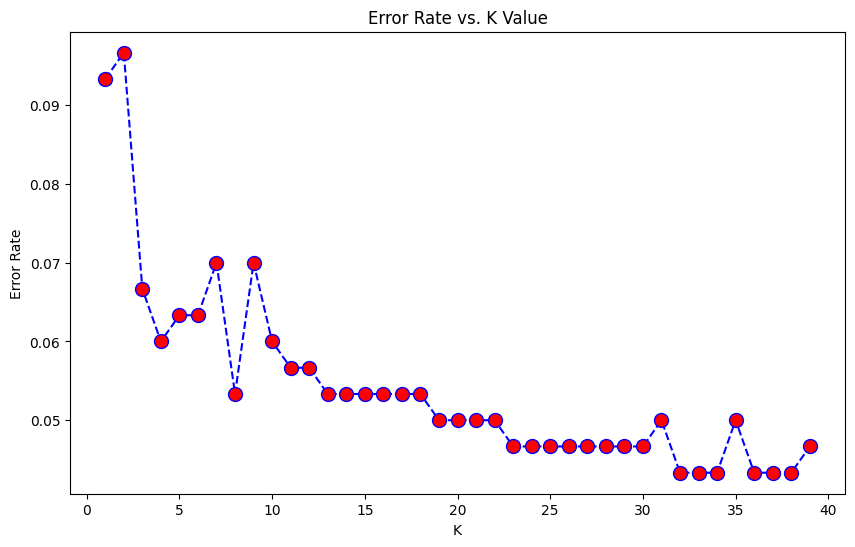

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

Interpret the result of the graph

<font color = blue> The value of k in the KNN algorithm is related to the error rate of the model. A small value of k could lead to overfitting as well as a big value of k can lead to underfitting. Overfitting imply that the model is well on the training data but has poor performance when new data is coming. </font>

Compare the classification report of K=1 and K=23

In [ ]:
# K = 1
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=1')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH K=1


[[137  15]
 [ 13 135]]


              precision    recall  f1-score   support

           0       0.91      0.90      0.91       152
           1       0.90      0.91      0.91       148

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300



In [ ]:
#K = 23
knn = KNeighborsClassifier(n_neighbors=23)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=23')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH K=23


[[143   9]
 [  5 143]]


              precision    recall  f1-score   support

           0       0.97      0.94      0.95       152
           1       0.94      0.97      0.95       148

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



Interpret the result of the graph.

<font color = blue> We can see that the accuracy of our data has been improved and tend to smooth out. from 0.91 we got 0.97 in precision, which imply that our model is good in classifying the dataset    </font>

Fit the K-nearest neighbors model again with `n_neighbors=3` but this time use distance for the weights. Calculate the accuracy using the function you created above.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3, weights='distance')

knn = knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.9333333333333333


Fit another K-nearest neighbors model. This time use uniform weights but set the power parameter for the Minkowski distance metric to be 1 (`p=1`) i.e. Manhattan Distance.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, p=1)

knn = knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.91


Fit a K-nearest neighbors model using values of `k` (`n_neighbors`) ranging from 1 to 20. Use uniform weights (the default). The coefficient for the Minkowski distance (`p`) can be set to either 1 or 2--just be consistent. Store the accuracy and the value of `k` used from each of these fits in a list or dictionary.
Plot (or view the table of) the `accuracy` vs `k`. What do you notice happens when `k=1`?

In [ ]:
# Fit the K-nearest neighbors model with different values of k
# Store the accuracy measurement for each k

score_list = list()

for k in range(1, 30):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn = knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    score_list.append((k, score))

score_df = pd.DataFrame(score_list, columns=['k', 'accuracy'])

In [ ]:
# Import libraries to make the plot

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

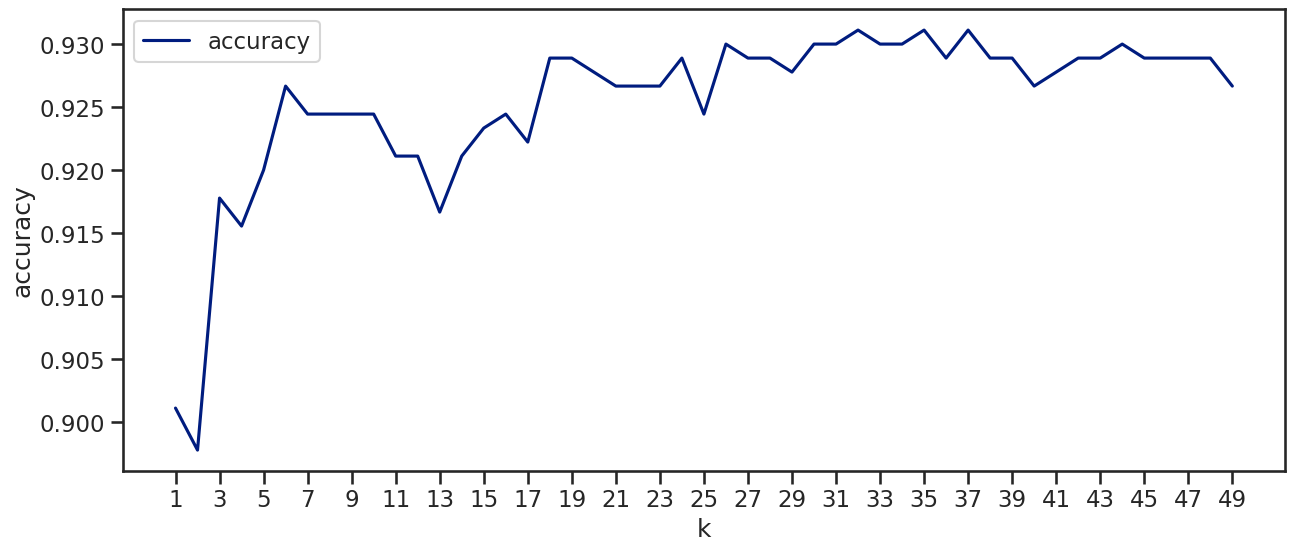

In [ ]:
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('dark')

ax = score_df.set_index('k').plot(figsize=(15,6))

ax.set(xlabel='k', ylabel='accuracy')
ax.set_xticks(range(1, 50, 2));

Supplementary Activities:

Supplementary Activity:
* Choose your own dataset
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values(NaN), replacing missing data .
* Standardize the variables.
* Perform descriptive statistics such as mean, median and mode
* Perform data visualization
* Build the model using K Nearest Neighbor. Use k value from 1 to 50.
* Evaluate the model using classification report, accuracy , confusion matrix and roc_auc_score
* Compare the model using their accuracy report.
* Create a graph to compare the accuracy based from eah k values.

## About dataset
 [Gene dataset](https://www.kaggle.com/datasets/alifarajnia/knngene/data)


In [ ]:
#import the dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
df = pd.read_csv("/content/KNN_Sample_Gene.csv")
df

,Gene1,Gene2,CancerPresent
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1
...,...,...,...
2995,5.0,6.5,1
2996,3.4,6.6,0
2997,2.7,6.5,0
2998,3.3,5.6,0


In [ ]:
#Determine the number of datapoint, columns and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Gene1          3000 non-null   float64
 1   Gene2          3000 non-null   float64
 2   CancerPresent  3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB


In [ ]:
#check null values
df.isnull().sum()

,0
Gene1,0
Gene2,0
CancerPresent,0


In [ ]:
#check NaN values
df.isna().sum()

,0
Gene1,0
Gene2,0
CancerPresent,0


In [ ]:


#check Missing Value
isNull = df.isnull().sum().to_frame(name='isNull').T
isNa = df.isna().sum().to_frame(name='isNa').T
Unique = df.nunique().to_frame(name='Unique').T
pd.concat([Unique , isNa , isNull])



,Gene1,Gene2,CancerPresent
Unique,89,88,2
isNa,0,0,0
isNull,0,0,0


In [ ]:
#standarize the variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df.drop('CancerPresent',axis=1))

StandardScaler()

In [ ]:
scaled_features = scaler.transform(df.drop('CancerPresent',axis=1))

In [ ]:
df_feat = pd.DataFrame(scaled_features,columns=df.columns[:-1])
df_feat.head()

,Gene1,Gene2
0,-0.711200,-0.873712
1,-1.695839,0.514540
2,0.054629,-0.873712
3,0.273438,0.456696
4,0.984565,-1.162931


In [ ]:
#Perform descriptive statistics such as mean, median and mode.
df.describe()


,Gene1,Gene2,CancerPresent
count,3000.000000,3000.000000,3000.000000
mean,5.600133,5.410467,0.500000
std,1.828388,1.729081,0.500083
min,1.000000,1.000000,0.000000
25%,4.300000,4.000000,0.000000
50%,5.600000,5.400000,0.500000
75%,6.900000,6.700000,1.000000
max,10.000000,10.000000,1.000000


array([[<Axes: title={'center': 'Gene1'}>,
        <Axes: title={'center': 'Gene2'}>],
       [<Axes: title={'center': 'CancerPresent'}>, <Axes: >]],
      dtype=object)

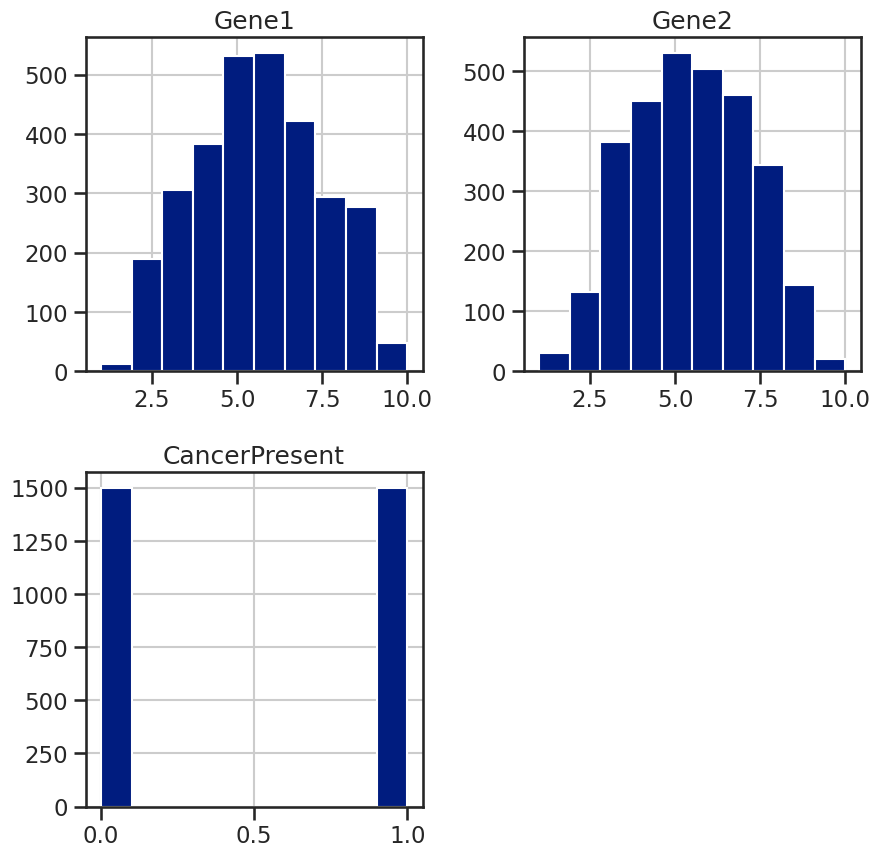

In [ ]:
#Perform data visualization.make a histogram
df.hist(figsize=(10,10))

([<matplotlib.axis.XTick at 0x7e88e5c87790>,
 [Text(1, 0, 'Gene1'), Text(2, 0, 'Gene2')])

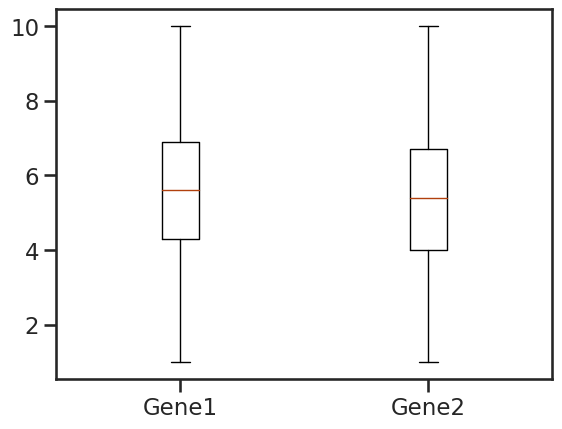

In [ ]:
#Boxplot for the gene1 and gene2 using numpy and matplotlib
gene1 = np.array(df['Gene1'])
gene2 = np.array(df['Gene2'])
plt.boxplot([gene1, gene2])
plt.xticks([1, 2], ['Gene1', 'Gene2'])

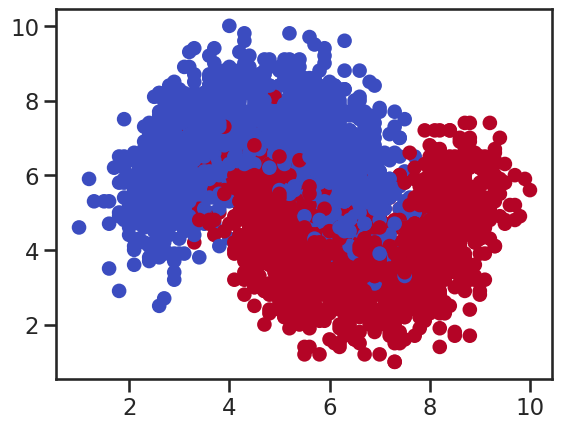

In [ ]:
#plot the scatter plot for the gene 1 (green ) and gene 2 (red)
plt.scatter(df['Gene1'], df['Gene2'], c=df['CancerPresent'], cmap='coolwarm')

In [ ]:
#Build the model using K Nearest Neighbor. Use k value from 1 to 50.
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(scaled_features,df['CancerPresent'],
                                                    test_size=0.30)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)

In [ ]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
pred = knn.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score

In [ ]:
print(confusion_matrix(y_test,pred))

[[420  32]
 [ 57 391]]


In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       452
           1       0.92      0.87      0.90       448

    accuracy                           0.90       900
   macro avg       0.90      0.90      0.90       900
weighted avg       0.90      0.90      0.90       900



In [ ]:
# for 1 to  50
error_rate = []


for i in range(1,50):

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

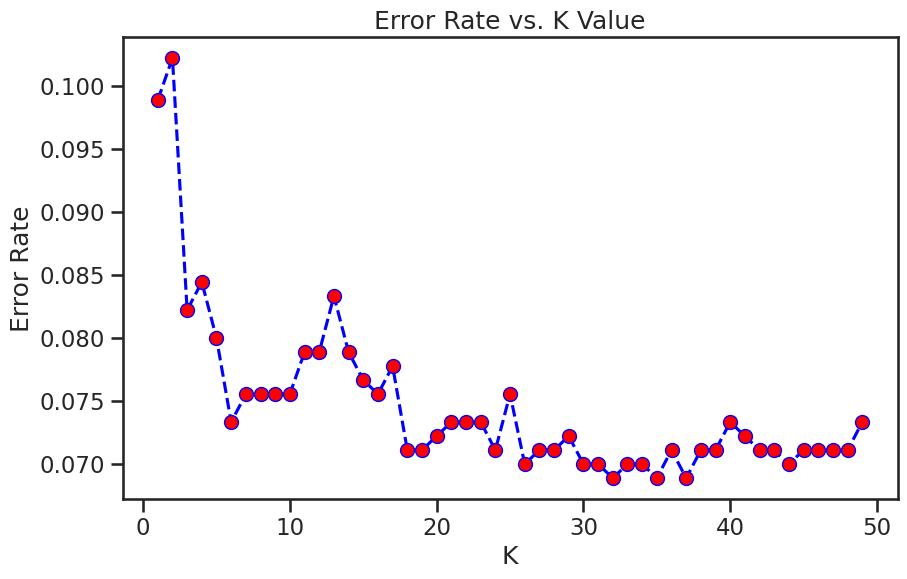

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1,50),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [ ]:
# K = 50
knn = KNeighborsClassifier(n_neighbors=50)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=50')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH K=50


[[426  26]
 [ 40 408]]


              precision    recall  f1-score   support

           0       0.91      0.94      0.93       452
           1       0.94      0.91      0.93       448

    accuracy                           0.93       900
   macro avg       0.93      0.93      0.93       900
weighted avg       0.93      0.93      0.93       900



In [ ]:
#K = 25
knn = KNeighborsClassifier(n_neighbors=25)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=25')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH K=25


[[422  30]
 [ 38 410]]


              precision    recall  f1-score   support

           0       0.92      0.93      0.93       452
           1       0.93      0.92      0.92       448

    accuracy                           0.92       900
   macro avg       0.92      0.92      0.92       900
weighted avg       0.92      0.92      0.92       900



In [ ]:
knn = KNeighborsClassifier(n_neighbors=3, weights='distance')

knn = knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.9122222222222223


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, p=1)

knn = knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.9211111111111111


In [ ]:
# Fit the K-nearest neighbors model with different values of k
# Store the accuracy measurement for each k

score_list = list()

for k in range(1, 50):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn = knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    score_list.append((k, score))

score_df = pd.DataFrame(score_list, columns=['k', 'accuracy'])

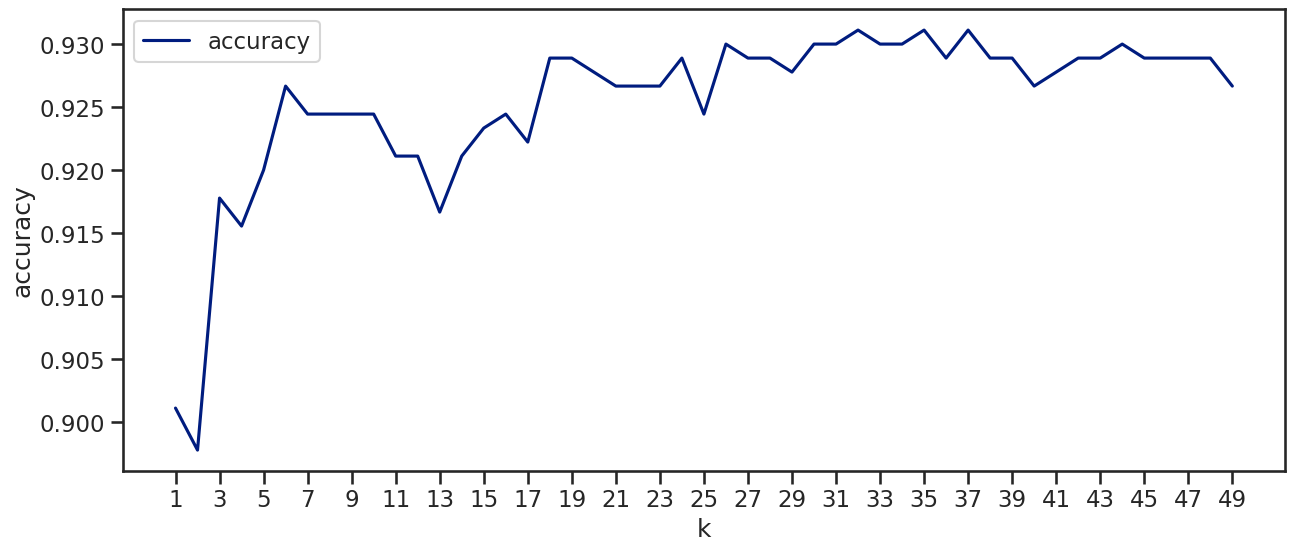

In [ ]:
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('dark')

ax = score_df.set_index('k').plot(figsize=(15,6))

ax.set(xlabel='k', ylabel='accuracy')
ax.set_xticks(range(1, 50,2));

Conclusion

<font color = green> In this activity, we learn that k nearest neighbors (KNN) algorithm is a non-parametric, supervised learning classifier, which uses proximity to make classifications or predictions about the grouping of an individual data point. We also tested some  dataset and compare each k values. We also made a model  using our own dataset.</font>

<font color= lightgreen> </font>